In [3]:
import pandas as pd

import numpy as np
import networkx as nx

from NEMtropy import UndirectedGraph, DirectedGraph, mof

from numpy import linalg as LA

from NEMtropy import matrix_generator as mg
from NEMtropy.network_functions import build_adjacency_from_edgelist

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from scipy.optimize import least_squares
import scipy.stats
from scipy.stats import pearsonr
from scipy.stats import zscore
import os
import warnings
warnings.filterwarnings("ignore")

from Dynamic_equations import compute_jacobian,equations_dinamiche,frobenius_eigen_difference, Numerical_abscissa,numerically_solve_equations_dinamiche,compute_tot_fluxes
from  Mass_Balance import Fluxes

In [1]:
import numpy as np

def replace_zeros_with_ones(vector):
    """
    Returns a copy of the input vector where all zero values 
    are replaced with ones.

    Parameters
    ----------
    vector : array-like (NumPy array)
        Input vector to process.

    Returns
    -------
    vector_modified : NumPy array
        Copy of the input vector with zeros replaced by ones.
    """

    # Copy the vector to avoid modifying the original input
    vector_modified = np.copy(vector)

    # Find the indices where the vector is equal to zero
    zero_indices = np.where(vector == 0)

    # Replace zeros with ones at the identified indices
    vector_modified[zero_indices] = 1

    return vector_modified


In [4]:
df = pd.ExcelFile('data/FoodWeb_vectorsFinal.xlsx')

In [5]:
d_i = np.asarray([1.84,1.6,1.84,1.2,1.84,1.84,1.08,4.36,1.92,2.68,1.2,1.2,1])/8760

e = np.asarray([0.906,0.906,0.158,0.158,0.158,0.545,0.545, 0.536, 0.158, 0.158,1,1,1])

topology = np.loadtxt('data/topology.txt')

In [18]:
# Create an empty DataFrame to store all computed ecosystem/network metrics.
# Each row will correspond to one site / location / treatment combination.
df_mesures = pd.DataFrame(
    columns=[
        'Location',                 # Geographic location of the site
        'Site',                     # Site identifier
        'Management',               # Management type
        'Treatment',                # Experimental treatment (e.g., drought vs control)
        'entropia',                 # Entropy
        'autovalore_massimo',       # Maximum eigenvalue of the interaction matrix
        'flusso_risorse_basali',    # Flux from basal resources
        'flusso_roots',             # Root-related energy/matter flux
        'flusso_fung',              # Fungal flux
        'flusso_bact',              # Bacterial flux
        'tot_fluxes',               # Total system flux
        'fract_non_feasible',       # Fraction of non-feasible systems
        'pvalue_autovalore_max',    # p-value associated with the maximum eigenvalue
        'Reactivity',               # Reactivity measure
    ]
)


### Entropy of the energy-flux network

In this section we construct the metrics used in the first part of the paper.
In particular, we compute the entropy of the maximum–entropy ensemble of
energy–flux networks (CReMa model), given the observed topology and the
empirical in– and out–fluxes. This entropy quantifies the number of typical
flux configurations compatible with the empirical constraints and is used as a
proxy for system resilience and intrinsic variability.


In [19]:
# Dictionaries used to store sampled quantities for each site/index i
biomasse_campionate = {}          # Sampled biomasses
autovalori_campionati = {}        # Sampled maximum eigenvalues
flussi_basali_campionati = {}     # Sampled basal fluxes

num_abscissa_camp = {}            # Sampled numerical abscissas
non_normal_camp = {}              # Sampled non-normality values

# Loop over all sites / configurations (here, 60)
for i in range(60):

    print(i)

    # Containers for the samples associated with the current index i
    biomasse_campionate_lista = []
    flussi_basali_campionati_lista = []
    autovalori_max = []
    num_abscissa_camp_list = []
    non_normal_camp_list = []

    # Read rate and biomass data for the i-th row from the Excel file
    rate_data = df.parse('Rates').values[i]
    biomasses_data = df.parse('BiomassData').values[i]

    # Extract rate parameters (indices 4 to 16 included)
    x_flussi = rate_data[4:17]

    # Special case: for row 23 we replace missing rates with the values
    # from the previous row and avoid zero biomasses
    if i == 23:  # Row 23 contains zeros / missing entries
        for ii in range(len(x_flussi)):
            if pd.isna(x_flussi[ii]):
                # Replace NaN with the value from the previous row (rounded)
                x_flussi[ii] = np.round(df.parse('Rates').values[i - 1][ii + 4], 2)

        for ii in range(len(biomasses_data)):
            if biomasses_data[ii] == 0:
                # Avoid exactly zero biomass (numerical stability)
                biomasses_data[ii] = 0.01

    # Initial biomasses (species start at column 4)
    initial_biomasses = np.round(np.float32(biomasses_data[4:]), 2)

    # Mortality vector m_finale (scaled by 0.01)
    m_finale = [d_i[i] * 0.01 for i in range(13)]

    # Compute stationary fluxes for the given topology and parameters
    flussi = Fluxes(topology, initial_biomasses, x_flussi, e, m_finale)
    flussi_prova, cost = flussi.solve()

    # Real outgoing and incoming fluxes for each node
    F_out_real = flussi_prova.sum(axis=1)
    F_in_real = flussi_prova.sum(axis=0)

    # Growth rates: zero for consumers, computed for basal nodes (indices 10–12)
    gr = np.append(
        np.zeros(10),
        [
            F_out_real[10] / initial_biomasses[10] + m_finale[10] * initial_biomasses[10],
            F_out_real[11] / initial_biomasses[11] + m_finale[11] * initial_biomasses[11],
            F_out_real[12] / initial_biomasses[12] + m_finale[12] * initial_biomasses[12],
        ],
    )

    # Jacobian matrix at the equilibrium point
    jacobiano = compute_jacobian(
        topology, flussi_prova, initial_biomasses, x_flussi, e, m_finale
    )

    # Eigenvalues / eigenvectors of the Jacobian
    w_real, v_real = LA.eig(jacobiano)

    # Numerical abscissa and non-normality of the Jacobian
    num_abscissa_real = Numerical_abscissa(jacobiano)
    non_normality_real = frobenius_eigen_difference(jacobiano)

    # Build weighted directed graph with given strength sequence
    graph_weighted = DirectedGraph(
        strength_sequence=np.concatenate([F_out_real, F_in_real])
    )

    # Fit the CREMA model using a Newton method from a random initial guess
    graph_weighted.solve_tool(
        model="crema",
        method="newton",
        initial_guess="random",
        adjacency=topology,
    )

    # CREMA parameters (out- and in-strengths and model arguments)
    b = np.concatenate((graph_weighted.b_out, graph_weighted.b_in))
    args = graph_weighted.args

    numero = 0  # Counter for “non-feasible” or unstable samples (see condition below)

    # Sample 1000 networks from the CREMA ensemble
    for ii in range(1000):

        # Draw one sample and save it to "sample_5/0.txt"
        graph_weighted.ensemble_sampler(1, cpu_n=2, output_dir="sample_1/")

        edgelist_ens = np.loadtxt("sample_1/0.txt")

        # Build the adjacency matrix of the sampled network
        ens_adj = build_adjacency_from_edgelist(
            edgelist=edgelist_ens,
            is_directed=True,
            is_sparse=False,
            is_weighted=True,
        )

        # Compute incoming / outgoing fluxes for the sampled network
        F_out = ens_adj.sum(axis=1)
        F_in = ens_adj.sum(axis=0)

        # Store sampled basal fluxes (indices 12, 10, 11)
        flussi_basali_campionati_lista.append([F_out[12], F_out[10], F_out[11]])

        # Rescale mortality terms for the sampled network
        m_sample = (
            np.concatenate([F_in_real[:10], F_out_real[10:]])
            / np.concatenate([F_in[:10], F_out[10:]])
            * m_finale
        )

        # Growth rates for the sampled network (basal nodes only)
        gr_samp = np.append(
            np.zeros(10),
            [
                F_out[10] / initial_biomasses[10] + m_sample[10] * initial_biomasses[10],
                F_out[11] / initial_biomasses[11] + m_sample[11] * initial_biomasses[11],
                F_out[12] / initial_biomasses[12] + m_sample[12] * initial_biomasses[12],
            ],
        )

        # Integrate the dynamical system for the sampled network
        # (biomasse_sample[0] = equilibrium biomasses, biomasse_sample[1] = some diagnostic)
        biomasse_sample = numerically_solve_equations_dinamiche(
            initial_biomasses, F_out, F_in, x_flussi, e, gr_samp, m_sample
        )

        # If the diagnostic is too large, we count the sample and skip storing the state
        if biomasse_sample[1] > 0.1:
            numero += 1
        else:
            # Store feasible equilibrium biomasses (rounded to 2 decimals)
            biomasse_campionate_lista.append(np.round(biomasse_sample[0], 2))

            try:
                # Jacobian for the sampled network at the sampled equilibrium
                jacobiano = compute_jacobian(
                    topology, ens_adj, biomasse_sample[0], x_flussi, e, m_sample
                )

                # Maximum eigenvalue (real part), numerical abscissa
                w, v = LA.eig(jacobiano)
                autovalori_max.append(max(w).real)

                num_abscissa_camp_list.append(Numerical_abscissa(jacobiano))
                non_normal_camp_list.append(frobenius_eigen_difference(jacobiano))

            except Exception as exc:
                print('Error while computing eigenvalues or Jacobian:', exc)
                continue

    # Store all sampled quantities for index i
    autovalori_campionati[i] = autovalori_max
    biomasse_campionate[i] = biomasse_campionate_lista
    flussi_basali_campionati[i] = flussi_basali_campionati_lista
    num_abscissa_camp[i] = num_abscissa_camp_list
    non_normal_camp[i] = non_normal_camp_list

    # Post-process eigenvalues of the real Jacobian
    autovalori_max = np.asarray(autovalori_max)
    autovalori_minori = autovalori_max[autovalori_max <= max(w_real)]

    # Store summary metrics in df_mesures for the current index i
    df_mesures.loc[i] = [
        rate_data[0],                             # Location
        rate_data[1],                             # Site
        rate_data[2],                             # Management
        rate_data[3],                             # Treatment
        -mof.loglikelihood_crema_directed(b, args),  # Entropy (CREMA log-likelihood)
        max(w_real).real,                         # Maximum eigenvalue (real part)
        F_out_real[10:].sum(),                    # Total basal fluxes
        F_out_real[12],                           # Root (?) flux (check ordering)
        F_out_real[10],                           # Fungal (?) flux
        F_out_real[11],                           # Bacterial (?) flux
        compute_tot_fluxes(flussi_prova),         # Total system flux
        numero,                                   # Number of "non-feasible" samples
        len(autovalori_minori),                   # Count of eigenvalues <= max(w_real)
        num_abscissa_real                        # Numerical abscissa of the real Jacobian
    ]


0

solution error = 1.628947143839099e-09
1

solution error = 6.940781283049091e-12
2

solution error = 1.522319163088648e-10
Error while computing eigenvalues or Jacobian: Array must not contain infs or NaNs
3

solution error = 3.053966524113605e-10
4

solution error = 2.2168933355715126e-12
Error while computing eigenvalues or Jacobian: Array must not contain infs or NaNs
5

solution error = 8.214665531136589e-09
6

solution error = 4.208053176746329e-11
7

solution error = 6.821210263296962e-13
8

solution error = 1.273900554488172e-09
9

solution error = 2.0463630789890885e-12
10

solution error = 4.744497247334556e-09
Error while computing eigenvalues or Jacobian: Array must not contain infs or NaNs
11

solution error = 5.714888631769277e-12
12

solution error = 2.13188366612882e-09
13

solution error = 7.958078640513122e-13
Error while computing eigenvalues or Jacobian: Array must not contain infs or NaNs
14

solution error = 1.3256370827441355e-12
15

solution error = 4.54747350

In [20]:
# Add the Coefficient of Variation (CV) of total biomass.
# This CV metric is the one used in the paper.
df_mesures['CV'] = df.parse('TotalN')['CV2']

# Add field (soil) moisture from the environmental dataset.
df_mesures['moisture'] = df.parse('EnvData')['fieldMoist']


### Construction of the heterogeneous component of entropy (S_het)

We now construct a proxy for the heterogeneous component of the entropy of
energy fluxes (S_het). Following the approach described in the Supporting
Information (Section 6), we normalise the total system flux so that all food
webs have the same total flow. In this way, entropy only reflects how the total
energy is distributed among trophic links, rather than depending on the total
amount of energy in the system.


In [21]:
# === Heterogeneous entropy component (S_het) ===
# We normalise total flux so that all systems share the same total flow.
# This removes the contribution of the total flux level and isolates the
# contribution of flux heterogeneity to entropy.

alphas = list(max(df_mesures['tot_fluxes']) / df_mesures['tot_fluxes'])
entropia_het = []

for i in range(60):

    # Extract rate and biomass data
    rate_data = df.parse('Rates').values[i]
    biomasses_data = df.parse('BiomassData').values[i]

    x_flussi = rate_data[4:17]

    # Handle missing values for site 23
    if i == 23:
        for ii in range(len(x_flussi)):
            if pd.isna(x_flussi[ii]):
                x_flussi[ii] = df.parse('Rates').values[i-1][ii+4]
        for ii in range(len(biomasses_data)):
            if biomasses_data[ii] == 0:
                biomasses_data[ii] = 0.01

    # Initial biomasses start from column 4
    initial_biomasses = biomasses_data[4:]

    # Mortality vector
    m_finale = [d_i[i]*0.01 for i in range(13)]

    # Compute equilibrium fluxes
    flussi = Fluxes(topology, initial_biomasses, x_flussi, e, m_finale)
    flussi_prova, cost = flussi.solve()

    # --- NORMALISATION STEP ---
    # We scale all fluxes by alpha so that each system has the same total flow.
    F_out_real = flussi_prova.sum(axis=1) * alphas[i]
    F_in_real = flussi_prova.sum(axis=0) * alphas[i]

    # Build CREMA graph with the normalised strength sequence
    graph_weighted = DirectedGraph(
        strength_sequence=np.concatenate([F_out_real, F_in_real])
    )

    graph_weighted.solve_tool(
        model="crema",
        method="newton",
        initial_guess="random",
        adjacency=topology
    )

    # Extract CREMA parameters
    b = np.concatenate((graph_weighted.b_out, graph_weighted.b_in))
    args = graph_weighted.args

    # Compute entropy of the normalised system
    entropia_het.append(-mof.loglikelihood_crema_directed(b, args))


# Add metric to dataframe
df_mesures['S_normalized'] = entropia_het



solution error = 8.071765478234738e-12

solution error = 1.9326762412674725e-12

solution error = 2.05773176276125e-11

solution error = 2.7284841053187847e-12

solution error = 1.2846612662542611e-11

solution error = 8.376585824976246e-08

solution error = 2.8421709430404007e-12

solution error = 1.4491819445849874e-09

solution error = 8.412825991399586e-12

solution error = 9.449649951420724e-09

solution error = 2.6147972675971687e-12

solution error = 1.1368683772161603e-12

solution error = 1.0479714145084085e-10

solution error = 2.112399200004944e-09

solution error = 3.637978807091713e-12

solution error = 2.5091848737668343e-11

solution error = 1.4088062313954985e-11

solution error = 9.322320693172514e-12

solution error = 3.143404113392645e-11

solution error = 1.566186311197093e-08

solution error = 2.204005207506743e-11

solution error = 4.246503161262072e-09

solution error = 7.73070496506989e-12

solution error = 2.172100721509196e-09

solution error = 6.934897101018

Note:
Normalising total flux ensures that entropy varies only because of the way
energy is partitioned across trophic links. Therefore, S_het isolates the
structural/heterogeneity contribution to entropy, independently of the
magnitude of total energy throughput.


# Checking the reproducibility of dynamical metrics
### Coefficient of variation of sampled biomasses

Here we illustrate the procedure only for the coefficient of variation (CV) of
(total) biomass. The same sampling and resampling scheme was applied to all
other dynamical metrics (e.g. maximum eigenvalue, and reactivity), and gave comparable levels of agreement between sampled and
measured values.


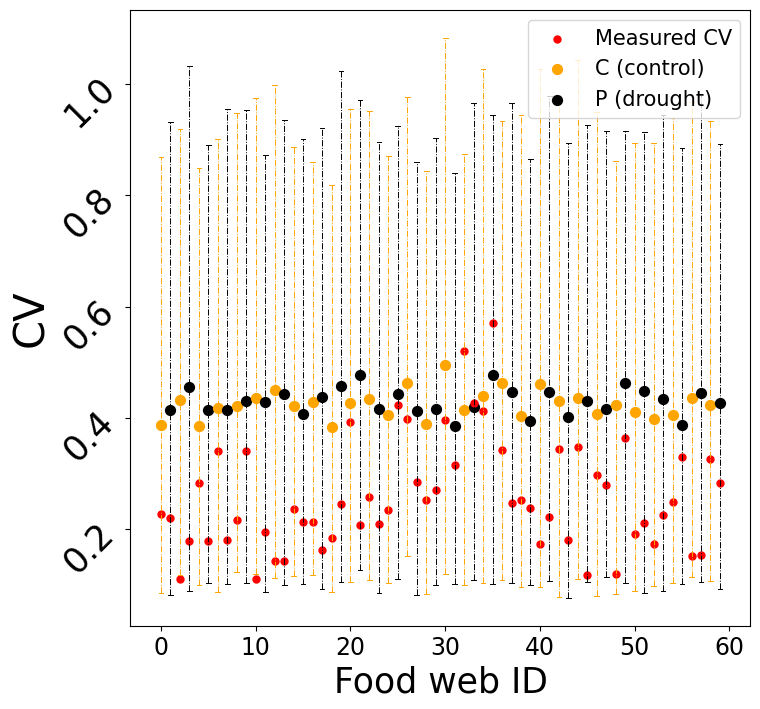

In [22]:
import random

# Dictionary storing, for each food web i, the distribution of sampled CV values
CV_sampled = {}

for i in range(60):
    # Replace zeros in the biomass vector to avoid divisions by zero
    # (this vector is used as a normalising factor).
    biomasses_unit = replace_zeros_with_ones(
        df.parse('FoodWebVectors').values[i][14:24]
    )

    cv_sampled_i = []

    # For each web i, draw 1000 bootstrap samples of equilibrium biomasses
    for _ in range(1000):
        # Randomly select 4 equilibrium biomass vectors from the ensemble
        bio_samples = random.choices(biomasse_campionate[i], k=4)

        totals = []
        for b in bio_samples:
            # Sum normalised biomasses of the first 10 consumer nodes
            totals.append(np.sum(b[:10] / biomasses_unit))

        totals = np.asarray(totals)

        # Coefficient of variation for this bootstrap sample
        cv_sampled_i.append(totals.std() / totals.mean())

    CV_sampled[i] = cv_sampled_i


# ---- Summary statistics across samples (per food web) ----
lista_CV_plot = []
stds = []
iqr = []
q1 = []
q3 = []

for i in range(60):
    lista_CV_plot.append(np.median(CV_sampled[i]))      # median CV
    stds.append(np.std(CV_sampled[i]))                  # std of CV distribution

    # Very conservative interval (1st–99th percentile)
    q1.append(np.percentile(CV_sampled[i], 1))
    q3.append(np.percentile(CV_sampled[i], 99))

    # Interquartile-like range based on 5th–95th percentiles
    q1_ = np.percentile(CV_sampled[i], 5)
    q3_ = np.percentile(CV_sampled[i], 95)
    iqr.append(q3_ - q1_)


# ---- Prepare data for plotting ----
measured_values = df.parse('TotalN')['CV2']

data = {
    "ID": [f"{i}" for i in range(60)],
    "Mean CV": lista_CV_plot,
    "Q1": q1,
    "Q3": q3,
    # Orange = control (C), black = perturbed (P)
    "Color": ["orange" if i % 2 == 0 else "black" for i in range(60)],
}

df_sup = pd.DataFrame(data)


# ---- Plot: sampled CV intervals vs measured CV ----
plt.figure(figsize=(8, 8))

cap_width = 0.5

for i, row in df_sup.iterrows():
    # Median (or “mean”) sampled CV
    plt.scatter(x=[i], y=[row['Mean CV']], color=row['Color'], s=50)
    # Vertical line for the (1st–99th percentile) interval
    plt.plot(
        [i, i], [row['Q1'], row['Q3']],
        color=row['Color'], alpha=1, linewidth=0.7, linestyle='-.'
    )
    # Caps at the extremes of the interval
    plt.plot(
        [i - cap_width/2, i + cap_width/2],
        [row['Q1'], row['Q1']],
        color=row['Color'], alpha=1, linewidth=0.7
    )
    plt.plot(
        [i - cap_width/2, i + cap_width/2],
        [row['Q3'], row['Q3']],
        color=row['Color'], alpha=1, linewidth=0.7
    )

# Measured CV (from empirical time series), plotted in red
plt.scatter(
    x=np.arange(len(measured_values)),
    y=measured_values,
    marker='o', color='r', s=25,
    label='Measured CV'
)

plt.yticks(rotation=45, size=25)
plt.xlabel('Food web ID', size=25)
plt.ylabel('CV', size=30)
plt.tick_params(axis='x', which='major', labelsize=17)

# Legend for control / perturbed colour coding
plt.scatter([], [], color='orange', label='C (control)', s=50)
plt.scatter([], [], color='black', label='P (drought)', s=50)

plt.legend(fontsize=15, loc='upper right')
#plt.savefig("Figure_Paper/CV_sampling.svg", format='svg')
plt.show()


### Total flux entropy component and its relation to CV

We now isolate the entropy contribution that depends on the *total* energy
throughput of the food web.

Recall that:

- `entropia` corresponds to the total entropy \(S\) of the CReMa ensemble,
- `S_normalized` corresponds to the heterogeneous component \(S_{\mathrm{het}}\),
  obtained after normalising the total flux so that all webs share the same
  total energy throughput.

By subtracting the two, we obtain a proxy for the extensive entropy component
associated purely with the level of total flux, denoted here as
\(S_{\mathrm{tot}}\):

$
S_{\mathrm{tot}} = S_{\mathrm{het}} - S.
$

This quantity increases when the total energy throughput of the system
increases, and is therefore expected to correlate with empirical variability
(e.g., the coefficient of variation of total biomass).


In [23]:
# Entropy contribution associated with total energy flux
df_mesures['S_tot_flux'] = df_mesures['S_normalized'] - df_mesures['entropia']


### Fluctuation–dissipation relation

We now compute the differences between drought (P) and control (C) treatment
for each pair of sites:

$
\Delta X = X_P - X_C .
$

In particular, we quantify:

- the change in soil moisture,
- the change in total energy flux,
- the change in the inverse “temperature-like” parameter
  \(\beta = 24 / F_{\mathrm{tot}}\),

which are later used to test the fluctuation–dissipation relation derived from
the maximum–entropy framework.


In [24]:
dif_fieldMoist = []
dif_tot_flux = []
dif_tot_beta = []

for i in range(30):

    # difference drought – control (P - C)
    dif_fieldMoist.append(
        df.parse('EnvData').loc[(i*2) + 1]['fieldMoist']
        - df.parse('EnvData').loc[i*2]['fieldMoist']
    )

    dif_tot_flux.append(
        df_mesures['tot_fluxes'][(i*2) + 1]
        - df_mesures['tot_fluxes'][(i*2)]
    )

    # beta = 24 / total_flux  (as defined in the paper)
    dif_tot_beta.append(
        24/df_mesures['tot_fluxes'][(i*2) + 1]
        - 24/df_mesures['tot_fluxes'][(i*2)]
    )

# Convert to NumPy arrays
dif_fieldMoist = np.asarray(dif_fieldMoist)
dif_tot_flux = np.asarray(dif_tot_flux)
dif_tot_beta = np.asarray(dif_tot_beta)


### Applying the fluctuation–dissipation theorem to total flux

We now test the fluctuation–dissipation relation for the total energy flux:

$
\frac{\Delta F_{\mathrm{tot}}}{\Delta \beta}
\approx
\mathrm{Var}(F_{\mathrm{tot}}),
\qquad
\beta = \frac{24}{F_{\mathrm{tot}}}.
$

For each control–drought pair we compute:

- $\Delta F_{\mathrm{tot}} = F_{\mathrm{tot}}^{(P)} - F_{\mathrm{tot}}^{(C)}$
- $\Delta \beta = \beta^{(P)} - \beta^{(C)}$
- $\mathrm{Var}(F_{\mathrm{tot}})$ predicted from the model.

The ratio $\Delta F_{\mathrm{tot}} / \Delta \beta$ (stored in `l1`) is then
compared with the predicted variance (`l2`).


In [25]:
l1 = []   # empirical FD ratio: ΔF_tot / Δβ
l2 = []   # predicted variance Var(F_tot)
l3 = []   # Δβ values

for i in range(30):

    # Control and drought total flux
    F_C = df_mesures['tot_fluxes'][i*2]
    F_P = df_mesures['tot_fluxes'][(i*2) + 1]

    # Differences (P − C)
    delta_F = F_P - F_C
    delta_beta = (24 / F_P) - (24 / F_C)

    # Variance predicted by the theory:
    # Var(F_tot) = 24 / beta^2  with beta = 24 / F_tot  (→ F_tot^2 / 24)
    var_F = 24 / (24 / F_C)**2

    # Store outputs
    l1.append(delta_F / delta_beta)
    l2.append(var_F)
    l3.append(delta_beta)

# Convert to arrays
l1 = np.asarray(l1)
l2 = np.asarray(l2)
l3 = np.asarray(l3)


### Fluctuation–dissipation relation for total flux

We now compare the empirical ratio
$
\frac{\Delta F_{\mathrm{tot}}}{\Delta \beta}
$
with the variance of the total flux at equilibrium, $\mathrm{Var}(F_{\mathrm{tot}}^C)$,
for each control–drought pair.

According to the fluctuation–dissipation relation derived in the paper, these
two quantities should be proportional, with slope close to 1 in the ideal case.
We fit a simple linear model and display the regression line together with a
95% confidence band.


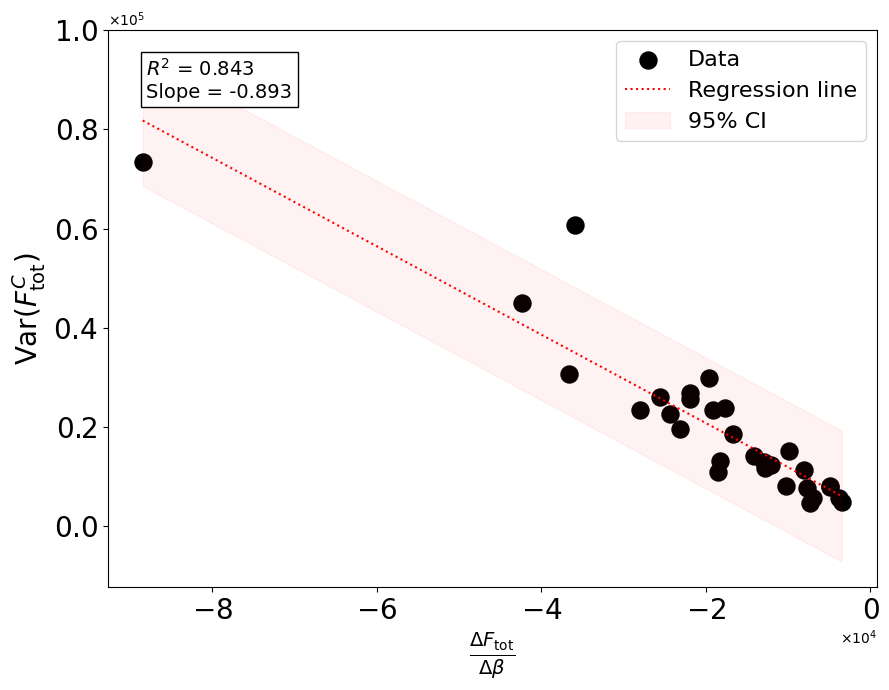

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.linear_model import LinearRegression
import scipy.stats as stats

fontsize = 20

X = l1.reshape(-1, 1)
y = l2

model = LinearRegression().fit(X, y)
slope = model.coef_[0]
intercept = model.intercept_
r_squared = model.score(X, y)

# Range per la retta
x_range = np.linspace(l1.min(), l1.max(), 200).reshape(-1, 1)
y_line = model.predict(x_range)

# Residual standard error (RMSE con df = n-2)
y_hat = model.predict(X)
residuals = y - y_hat
n = len(y)
rmse = np.sqrt(np.sum(residuals**2) / (n - 2))

# Banda costante (95% ~ t_{0.975, n-2} * rmse)
t_val = stats.t.ppf(0.975, df=n-2)
band = t_val * rmse

ci_upper = y_line + band
ci_lower = y_line - band

plt.figure(figsize=(9, 7))

plt.scatter(l1, l2, color='black', s=150, label='Data')
plt.plot(x_range.flatten(), y_line, color='red', linestyle=':', linewidth=1.5,
         label='Regression line')

plt.fill_between(x_range.flatten(), ci_lower, ci_upper,
                 color='red', alpha=0.05, label='95% CI')

plt.xlabel(r'$\frac{\Delta F_{\mathrm{tot}}}{\Delta \beta}$', fontsize=fontsize)
plt.ylabel(r'$\mathrm{Var}(F_{\mathrm{tot}}^C)$', fontsize=fontsize)

plt.xticks(fontsize=fontsize)
plt.yticks(fontsize=fontsize)

plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.gca().xaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.gca().text(
    0.05, 0.95,
    f'$R^2$ = {r_squared:.3f}\nSlope = {slope:.3f}',
    transform=plt.gca().transAxes,
    fontsize=14,
    va='top',
    bbox=dict(facecolor='white', edgecolor='black')
)

plt.legend(fontsize=fontsize - 4, loc='upper right')
plt.tight_layout()
plt.show()
